<a href="https://www.kaggle.com/code/lalit7881/multi-coin-crypto-daily-market-eda?scriptVersionId=326252117" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fleongg/multi-coin-crypto-daily-market-dataset/crypto_daily.csv
/kaggle/input/datasets/fleongg/multi-coin-crypto-daily-market-dataset/crypto_daily.parquet


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/fleongg/multi-coin-crypto-daily-market-dataset/crypto_daily.csv")

In [3]:
df.head()

,date,symbol,name,open,high,low,close,adj_close,volume,return_1d,...,btc_n_transactions,btc_active_addresses,btc_est_tx_volume_usd,btc_miner_revenue_usd,btc_tx_fees_usd,btc_circulating_supply,year,month,day_of_week,is_weekend
0,2017-11-09,ADA,Cardano,0.025160,0.035060,0.025006,0.032053,0.032053,18716200,NaN,...,341281.0,727946.0,2.366841e+09,1.667847e+07,2.653879e+06,16673000.0,2017,11,3,0
1,2017-11-10,ADA,Cardano,0.032219,0.033348,0.026451,0.027119,0.027119,6766780,-0.153933,...,271745.0,619944.0,2.022294e+09,1.271307e+07,2.226674e+06,16674500.0,2017,11,4,0
2,2017-11-11,ADA,Cardano,0.026891,0.029659,0.025684,0.027437,0.027437,5532220,0.011726,...,197081.0,459977.0,1.401934e+09,8.785091e+06,2.122955e+06,16675512.5,2017,11,5,1
3,2017-11-12,ADA,Cardano,0.027480,0.027952,0.022591,0.023977,0.023977,7280250,-0.126107,...,183519.0,463412.0,1.946783e+09,9.479345e+06,3.495448e+06,16676500.0,2017,11,6,1
4,2017-11-13,ADA,Cardano,0.024364,0.026300,0.023495,0.025808,0.025808,4419440,0.076365,...,309299.0,694905.0,2.070830e+09,1.620952e+07,4.999532e+06,16678250.0,2017,11,0,0


In [4]:
df.tail()

,date,symbol,name,open,high,low,close,adj_close,volume,return_1d,...,btc_n_transactions,btc_active_addresses,btc_est_tx_volume_usd,btc_miner_revenue_usd,btc_tx_fees_usd,btc_circulating_supply,year,month,day_of_week,is_weekend
30565,2026-06-05,XRP,XRP,1.166648,1.171313,1.070939,1.096436,1.096436,4104684182,-0.060182,...,588281.0,538439.0,1.104466e+10,3.199442e+07,285283.879998,20039087.5,2026,6,4,0
30566,2026-06-06,XRP,XRP,1.096444,1.112817,1.054657,1.093458,1.093458,2190389936,-0.002716,...,588281.0,538439.0,1.104466e+10,3.199442e+07,285283.879998,20039087.5,2026,6,5,1
30567,2026-06-07,XRP,XRP,1.093465,1.166491,1.089772,1.154651,1.154651,2135757215,0.055963,...,588281.0,538439.0,1.104466e+10,3.199442e+07,285283.879998,20039087.5,2026,6,6,1
30568,2026-06-08,XRP,XRP,1.154645,1.184806,1.132768,1.168193,1.168193,2123608548,0.011728,...,588281.0,538439.0,1.104466e+10,3.199442e+07,285283.879998,20039087.5,2026,6,0,0
30569,2026-06-09,XRP,XRP,1.168110,1.175169,1.144344,1.161300,1.161300,2015069952,-0.005901,...,588281.0,538439.0,1.104466e+10,3.199442e+07,285283.879998,20039087.5,2026,6,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30570 entries, 0 to 30569
Data columns (total 52 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    30570 non-null  object 
 1   symbol                  30570 non-null  object 
 2   name                    30570 non-null  object 
 3   open                    30570 non-null  float64
 4   high                    30570 non-null  float64
 5   low                     30570 non-null  float64
 6   close                   30570 non-null  float64
 7   adj_close               30570 non-null  float64
 8   volume                  30570 non-null  int64  
 9   return_1d               30560 non-null  float64
 10  return_7d               30500 non-null  float64
 11  return_30d              30270 non-null  float64
 12  log_return_1d           30560 non-null  float64
 13  sma_7                   30510 non-null  float64
 14  sma_30                  30280 non-null

In [6]:
df.describe()

,open,high,low,close,adj_close,volume,return_1d,return_7d,return_30d,log_return_1d,...,btc_n_transactions,btc_active_addresses,btc_est_tx_volume_usd,btc_miner_revenue_usd,btc_tx_fees_usd,btc_circulating_supply,year,month,day_of_week,is_weekend
count,30570.000000,30570.000000,30570.000000,30570.000000,30570.000000,3.057000e+04,30560.000000,30500.000000,30270.000000,30560.000000,...,30570.000000,3.057000e+04,3.057000e+04,3.057000e+04,3.057000e+04,3.057000e+04,30570.000000,30570.000000,30570.000000,30570.000000
mean,4232.588077,4317.680145,4141.668194,4234.534814,4234.534814,5.703457e+09,0.002638,0.021171,0.132929,0.001072,...,350365.686457,5.831560e+05,4.360359e+09,2.936373e+07,1.334509e+06,1.874300e+07,2021.619136,6.452437,3.000033,0.285770
std,15656.072070,15936.934879,15353.906555,15659.215375,15659.215375,1.250989e+10,0.060169,0.209527,1.188090,0.054840,...,131915.300973,1.220039e+05,4.348675e+09,1.636547e+07,2.817402e+06,1.158002e+06,2.672849,3.488218,2.000303,0.451788
min,0.001046,0.001210,0.001002,0.001038,0.001038,3.957000e+03,-0.459130,-0.604551,-0.828011,-0.614577,...,59344.000000,1.175290e+05,2.465224e+07,6.728124e+05,2.817502e+03,1.328112e+07,2014.000000,1.000000,0.000000,0.000000
25%,0.281190,0.288227,0.273150,0.281177,0.281177,2.692693e+08,-0.021178,-0.058583,-0.134210,-0.021405,...,263410.000000,4.970810e+05,1.280348e+09,1.598329e+07,2.655353e+05,1.818910e+07,2020.000000,3.000000,1.000000,0.000000
50%,11.092287,11.470403,10.662370,11.098957,11.098957,9.575220e+08,0.000375,0.000633,0.004451,0.000375,...,315443.000000,5.732770e+05,2.775748e+09,2.762780e+07,5.036246e+05,1.900195e+07,2022.000000,6.000000,3.000000,0.000000
75%,322.624313,331.138840,315.078529,322.770081,322.770081,3.623272e+09,0.021745,0.067995,0.174986,0.021512,...,414799.000000,6.729120e+05,6.187880e+09,4.163759e+07,1.082769e+06,1.969494e+07,2024.000000,10.000000,5.000000,1.000000
max,124752.140625,126198.070312,123196.046875,124752.531250,124752.531250,3.509679e+11,3.555466,7.441689,98.747721,1.516328,...,927010.000000,1.072862e+06,5.838867e+10,1.077559e+08,8.105034e+07,2.003909e+07,2026.000000,12.000000,6.000000,1.000000


In [7]:
df.isnull()

,date,symbol,name,open,high,low,close,adj_close,volume,return_1d,...,btc_n_transactions,btc_active_addresses,btc_est_tx_volume_usd,btc_miner_revenue_usd,btc_tx_fees_usd,btc_circulating_supply,year,month,day_of_week,is_weekend
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
30568,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

date                         0
symbol                       0
name                         0
open                         0
high                         0
low                          0
close                        0
adj_close                    0
volume                       0
return_1d                   10
return_7d                   70
return_30d                 300
log_return_1d               10
sma_7                       60
sma_30                     290
sma_90                     890
ema_12                       0
ema_26                       0
rsi_14                     140
macd                         0
macd_signal                  0
macd_hist                    0
bb_mid_20                  190
bb_upper                   190
bb_lower                   190
bb_width                   190
atr_14                     130
volatility_30d             300
hl_range_pct                 0
volume_sma_7                60
close_btc_ratio              0
feargreed_value           1821
feargree

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

date                       object
symbol                     object
name                       object
open                      float64
high                      float64
low                       float64
close                     float64
adj_close                 float64
volume                      int64
return_1d                 float64
return_7d                 float64
return_30d                float64
log_return_1d             float64
sma_7                     float64
sma_30                    float64
sma_90                    float64
ema_12                    float64
ema_26                    float64
rsi_14                    float64
macd                      float64
macd_signal               float64
macd_hist                 float64
bb_mid_20                 float64
bb_upper                  float64
bb_lower                  float64
bb_width                  float64
atr_14                    float64
volatility_30d            float64
hl_range_pct              float64
volume_sma_7  

In [11]:
df.shape

(30570, 52)

In [12]:
df.columns

Index(['date', 'symbol', 'name', 'open', 'high', 'low', 'close', 'adj_close',
       'volume', 'return_1d', 'return_7d', 'return_30d', 'log_return_1d',
       'sma_7', 'sma_30', 'sma_90', 'ema_12', 'ema_26', 'rsi_14', 'macd',
       'macd_signal', 'macd_hist', 'bb_mid_20', 'bb_upper', 'bb_lower',
       'bb_width', 'atr_14', 'volatility_30d', 'hl_range_pct', 'volume_sma_7',
       'close_btc_ratio', 'feargreed_value', 'feargreed_class', 'mkt_sp500',
       'mkt_nasdaq', 'mkt_gold', 'mkt_oil', 'mkt_vix', 'mkt_us10y', 'mkt_dxy',
       'btc_hashrate_thps', 'btc_difficulty', 'btc_n_transactions',
       'btc_active_addresses', 'btc_est_tx_volume_usd',
       'btc_miner_revenue_usd', 'btc_tx_fees_usd', 'btc_circulating_supply',
       'year', 'month', 'day_of_week', 'is_weekend'],
      dtype='object')

In [13]:
df.dtypes

date                       object
symbol                     object
name                       object
open                      float64
high                      float64
low                       float64
close                     float64
adj_close                 float64
volume                      int64
return_1d                 float64
return_7d                 float64
return_30d                float64
log_return_1d             float64
sma_7                     float64
sma_30                    float64
sma_90                    float64
ema_12                    float64
ema_26                    float64
rsi_14                    float64
macd                      float64
macd_signal               float64
macd_hist                 float64
bb_mid_20                 float64
bb_upper                  float64
bb_lower                  float64
bb_width                  float64
atr_14                    float64
volatility_30d            float64
hl_range_pct              float64
volume_sma_7  

In [14]:
df.shape

(30570, 52)

In [15]:
df.nunique()

date                       4284
symbol                       10
name                         10
open                      30213
high                      30195
low                       30171
close                     30211
adj_close                 30211
volume                    30565
return_1d                 30510
return_7d                 30482
return_30d                30268
log_return_1d             30511
sma_7                     30450
sma_30                    30262
sma_90                    29673
ema_12                    30561
ema_26                    30568
rsi_14                    30420
macd                      30503
macd_signal               30503
macd_hist                 30400
bb_mid_20                 30355
bb_upper                  30375
bb_lower                  30375
bb_width                  30367
atr_14                    30178
volatility_30d            30195
hl_range_pct              30569
volume_sma_7              30510
close_btc_ratio           16833
feargree

## EDA

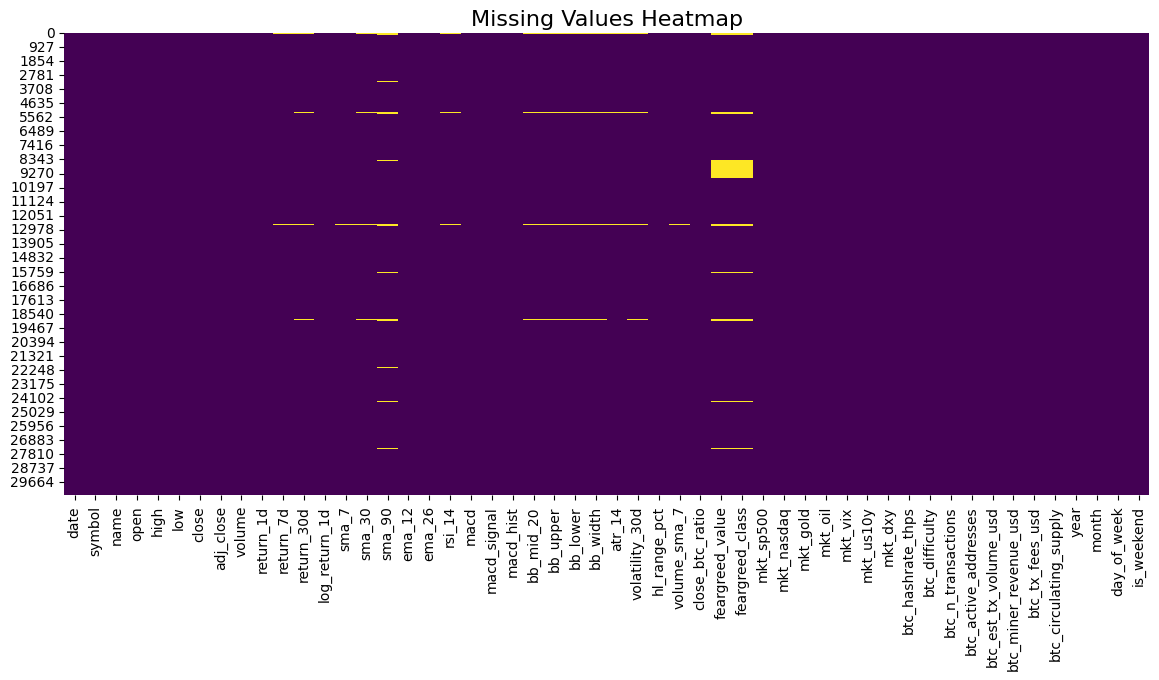

In [16]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap', fontsize=16)
plt.show()

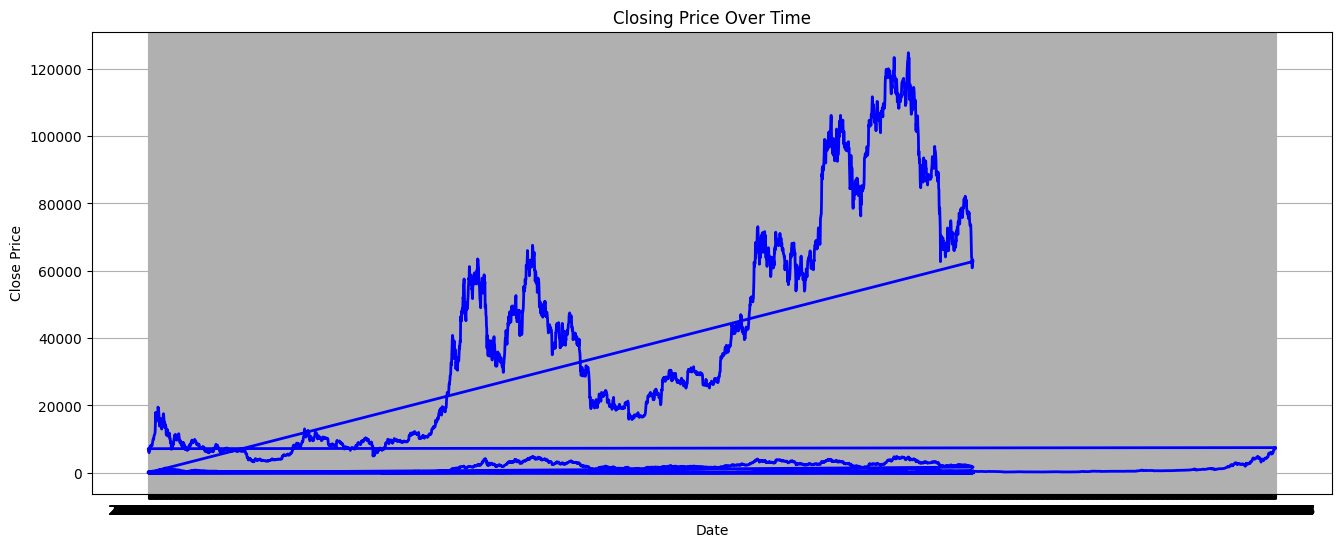

In [17]:
plt.figure(figsize=(16,6))
plt.plot(df['date'], df['close'],
         color='blue',
         linewidth=2)

plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

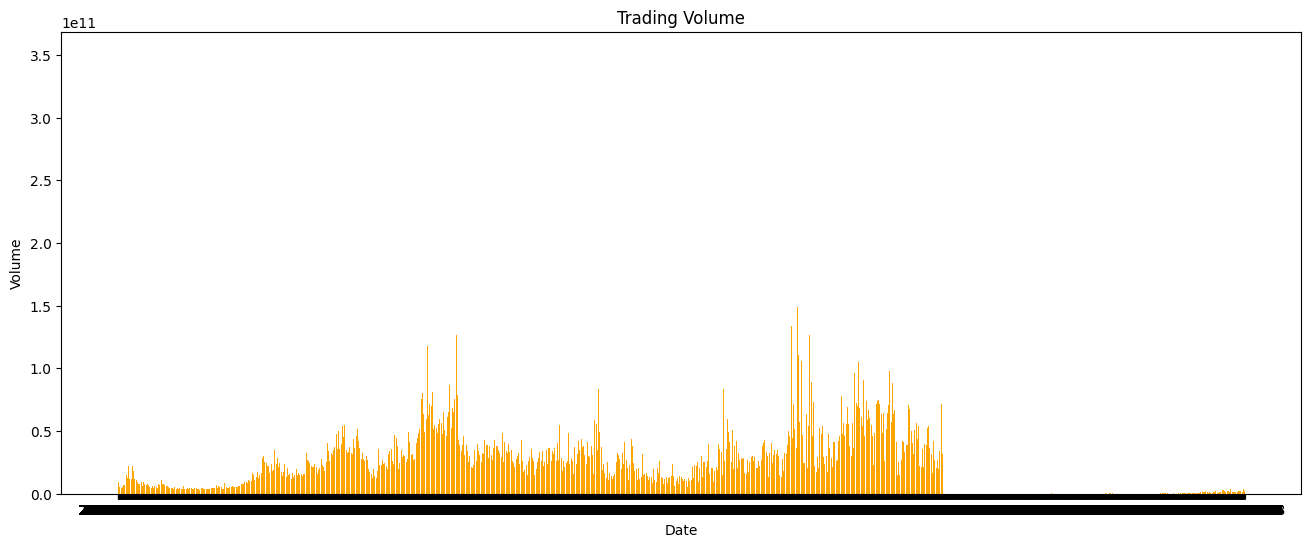

In [18]:
plt.figure(figsize=(16,6))
plt.bar(df['date'],
        df['volume'],
        color='orange')

plt.title('Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

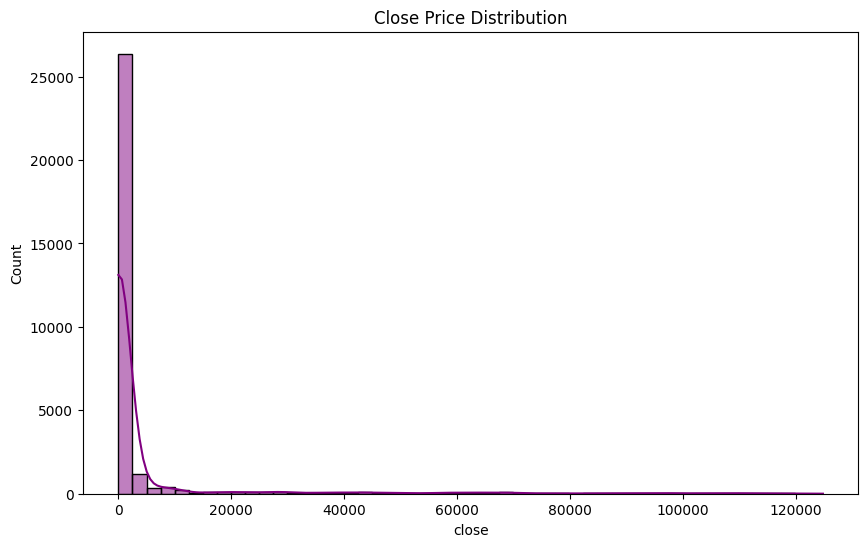

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(df['close'],
             bins=50,
             kde=True,
             color='purple')

plt.title('Close Price Distribution')
plt.show()

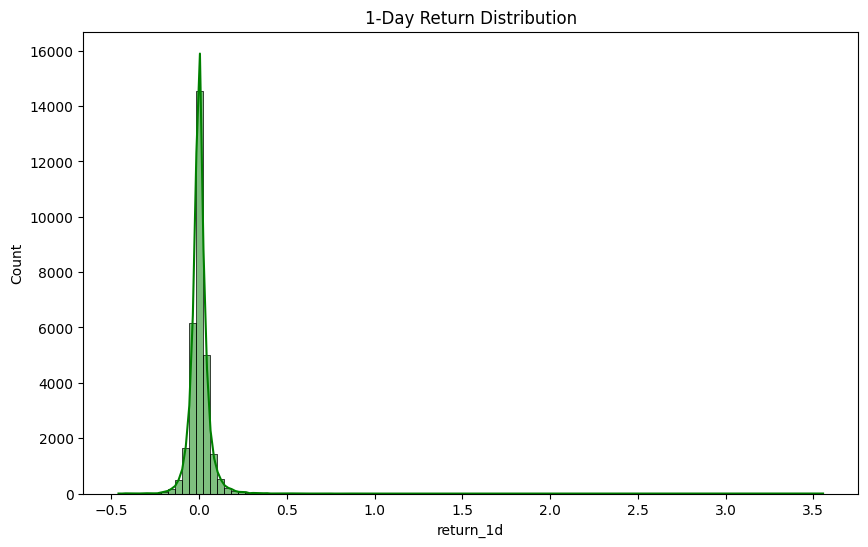

In [20]:
plt.figure(figsize=(10,6))

sns.histplot(df['return_1d'],
             bins=100,
             kde=True,
             color='green')

plt.title('1-Day Return Distribution')
plt.show()

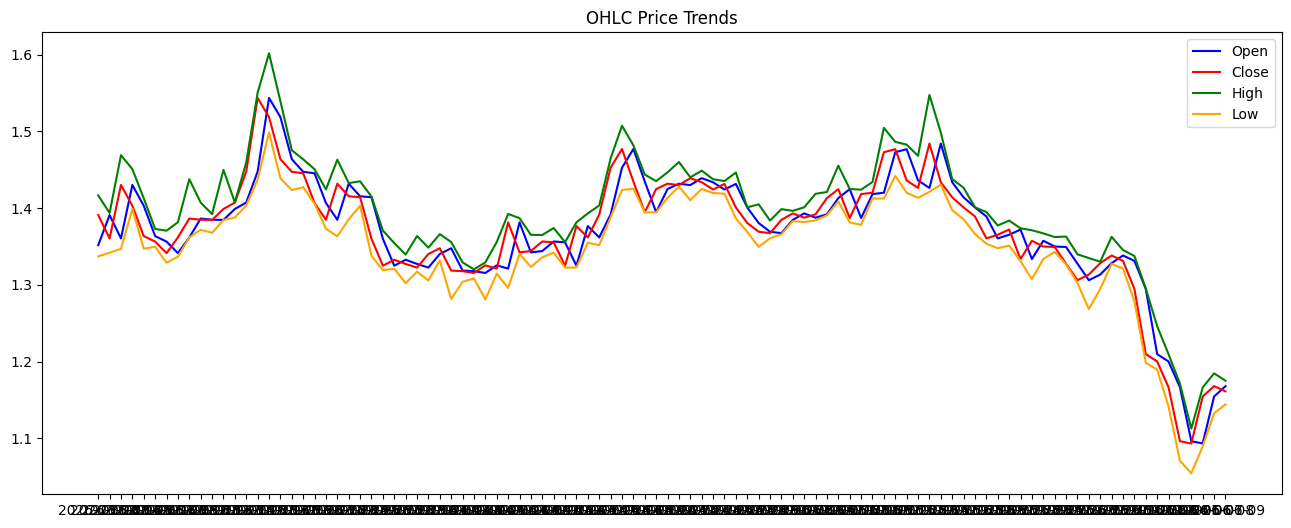

In [21]:
sample = df.tail(100)

plt.figure(figsize=(16,6))

plt.plot(sample['date'],
         sample['open'],
         label='Open',
         color='blue')

plt.plot(sample['date'],
         sample['close'],
         label='Close',
         color='red')

plt.plot(sample['date'],
         sample['high'],
         label='High',
         color='green')

plt.plot(sample['date'],
         sample['low'],
         label='Low',
         color='orange')

plt.legend()
plt.title('OHLC Price Trends')
plt.show()

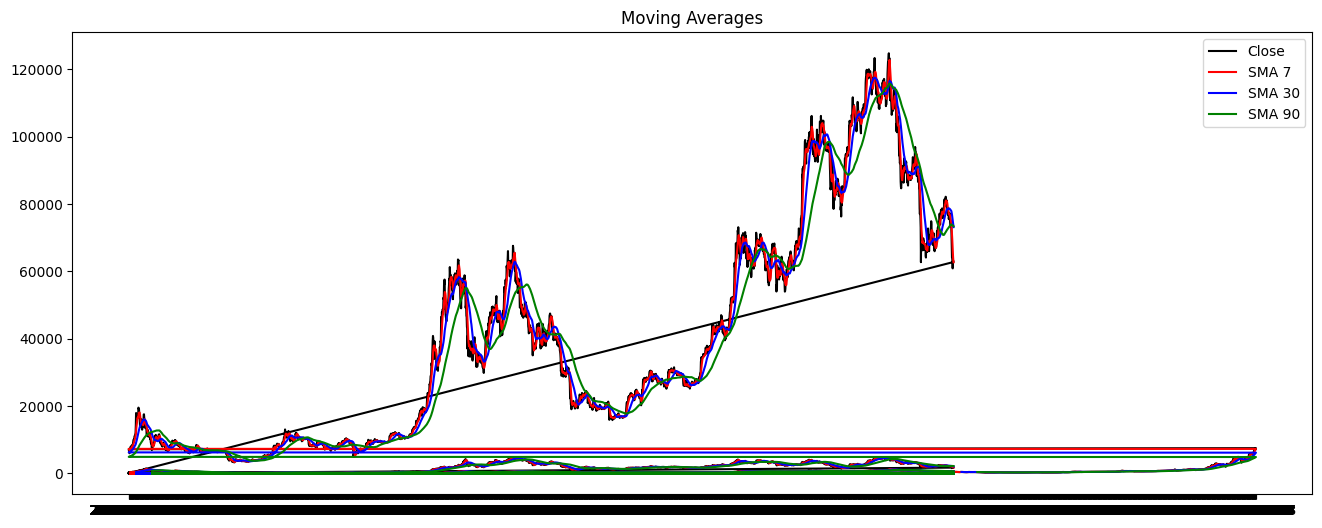

In [22]:
plt.figure(figsize=(16,6))

plt.plot(df['date'], df['close'],
         label='Close',
         color='black')

plt.plot(df['date'], df['sma_7'],
         label='SMA 7',
         color='red')

plt.plot(df['date'], df['sma_30'],
         label='SMA 30',
         color='blue')

plt.plot(df['date'], df['sma_90'],
         label='SMA 90',
         color='green')

plt.legend()
plt.title('Moving Averages')
plt.show()

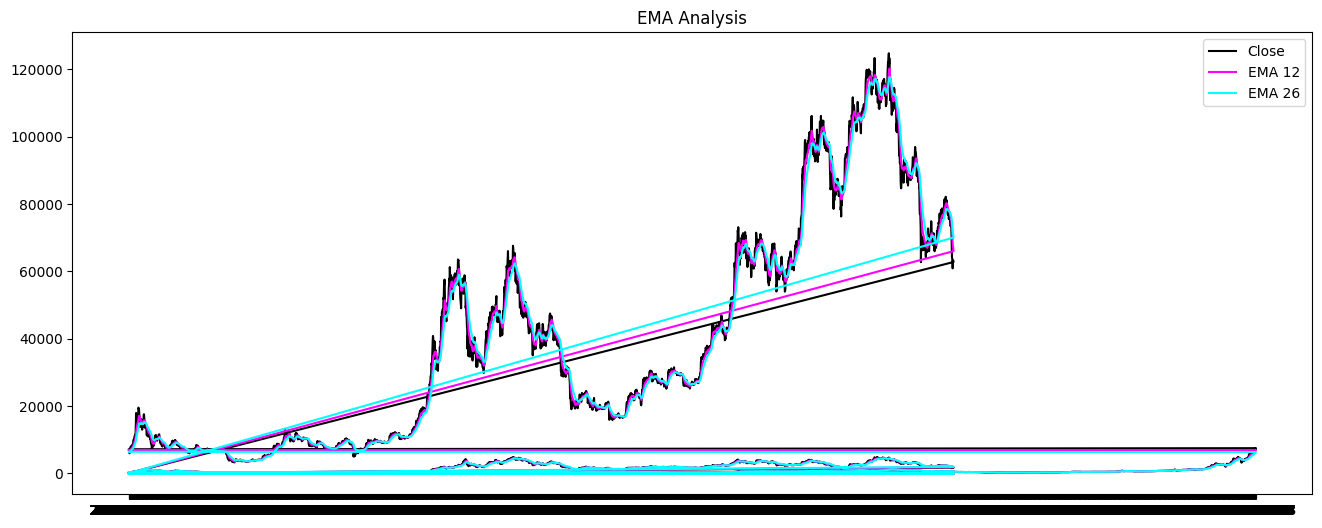

In [23]:
plt.figure(figsize=(16,6))

plt.plot(df['date'], df['close'],
         color='black',
         label='Close')

plt.plot(df['date'], df['ema_12'],
         color='magenta',
         label='EMA 12')

plt.plot(df['date'], df['ema_26'],
         color='cyan',
         label='EMA 26')

plt.legend()
plt.title('EMA Analysis')
plt.show()

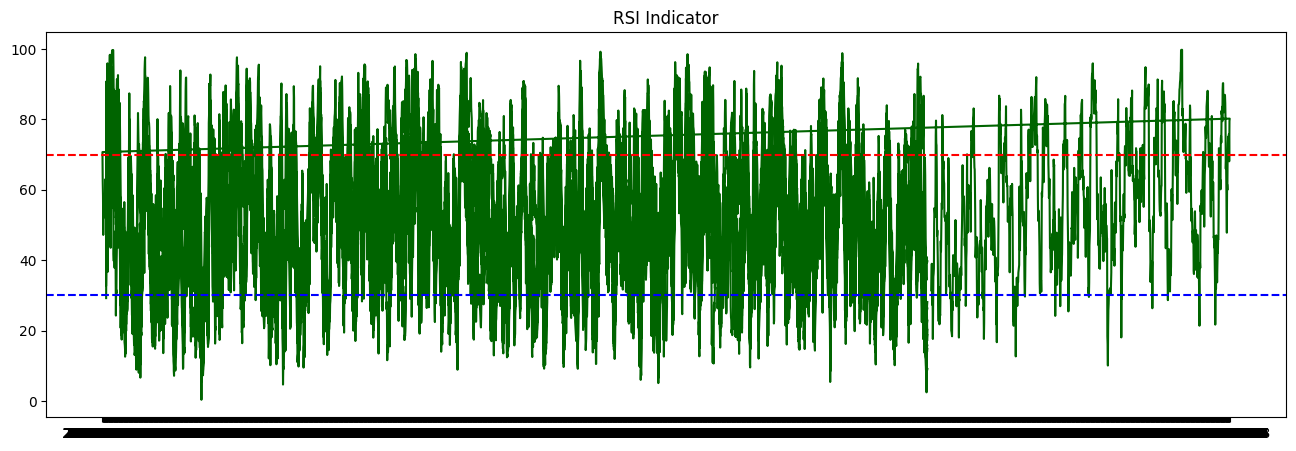

In [24]:
plt.figure(figsize=(16,5))

plt.plot(df['date'],
         df['rsi_14'],
         color='darkgreen')

plt.axhline(70,
            color='red',
            linestyle='--')

plt.axhline(30,
            color='blue',
            linestyle='--')

plt.title('RSI Indicator')
plt.show()

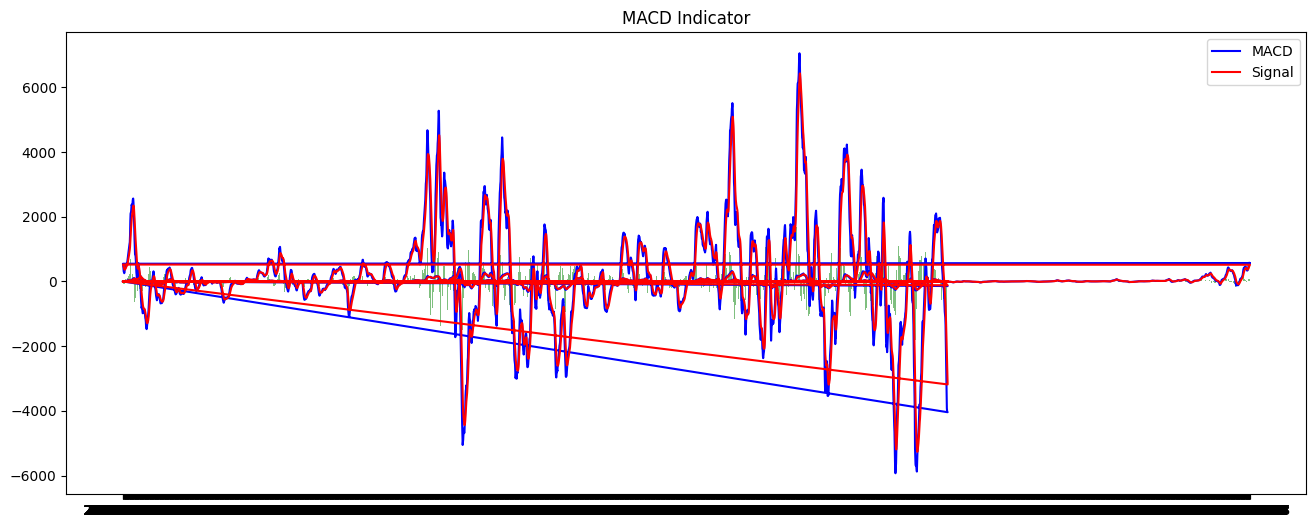

In [25]:
plt.figure(figsize=(16,6))

plt.plot(df['date'],
         df['macd'],
         color='blue',
         label='MACD')

plt.plot(df['date'],
         df['macd_signal'],
         color='red',
         label='Signal')

plt.bar(df['date'],
        df['macd_hist'],
        color='green',
        alpha=0.5)

plt.legend()
plt.title('MACD Indicator')
plt.show()

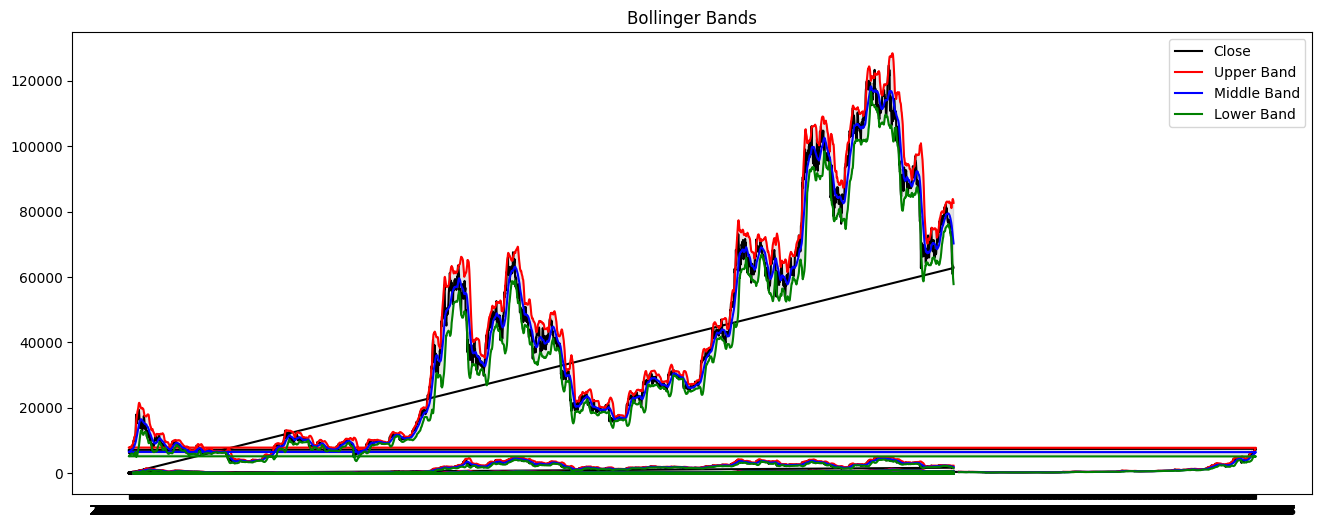

In [26]:
plt.figure(figsize=(16,6))

plt.plot(df['date'],
         df['close'],
         color='black',
         label='Close')

plt.plot(df['date'],
         df['bb_upper'],
         color='red',
         label='Upper Band')

plt.plot(df['date'],
         df['bb_mid_20'],
         color='blue',
         label='Middle Band')

plt.plot(df['date'],
         df['bb_lower'],
         color='green',
         label='Lower Band')

plt.fill_between(df['date'],
                 df['bb_upper'],
                 df['bb_lower'],
                 color='gray',
                 alpha=0.2)

plt.legend()
plt.title('Bollinger Bands')
plt.show()

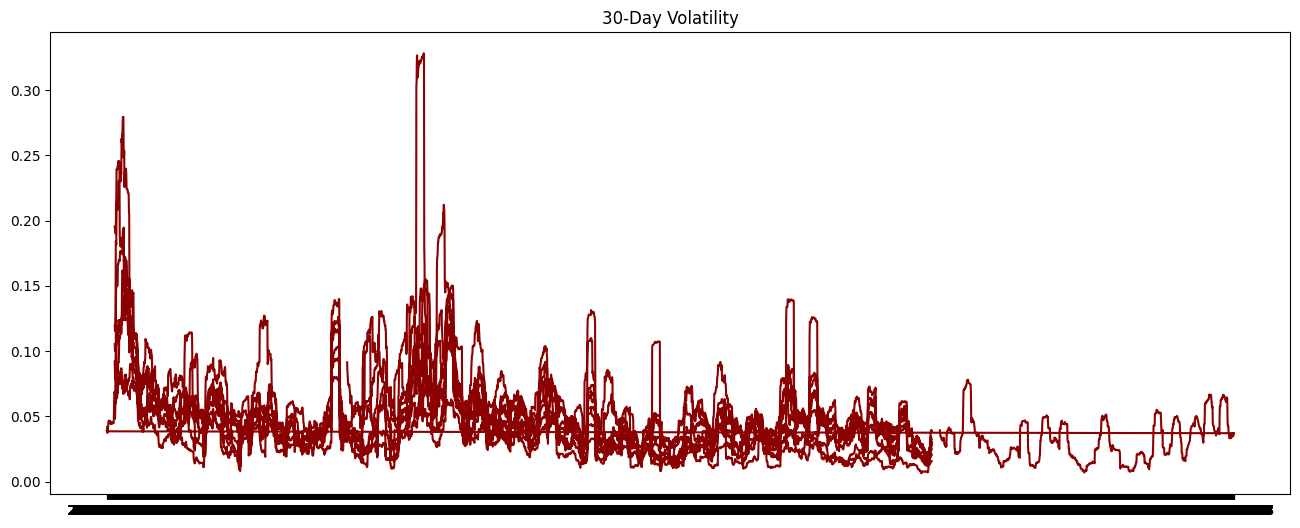

In [27]:
plt.figure(figsize=(16,6))

plt.plot(df['date'],
         df['volatility_30d'],
         color='darkred')

plt.title('30-Day Volatility')
plt.show()

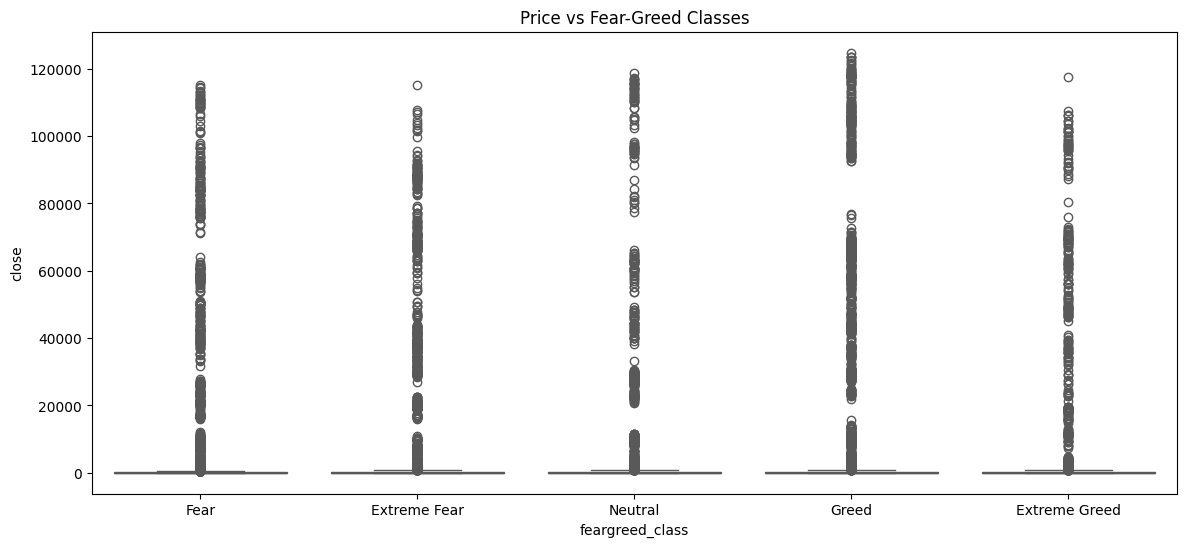

In [28]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='feargreed_class',
    y='close',
    data=df,
    palette='Set2'
)

plt.title('Price vs Fear-Greed Classes')
plt.show()

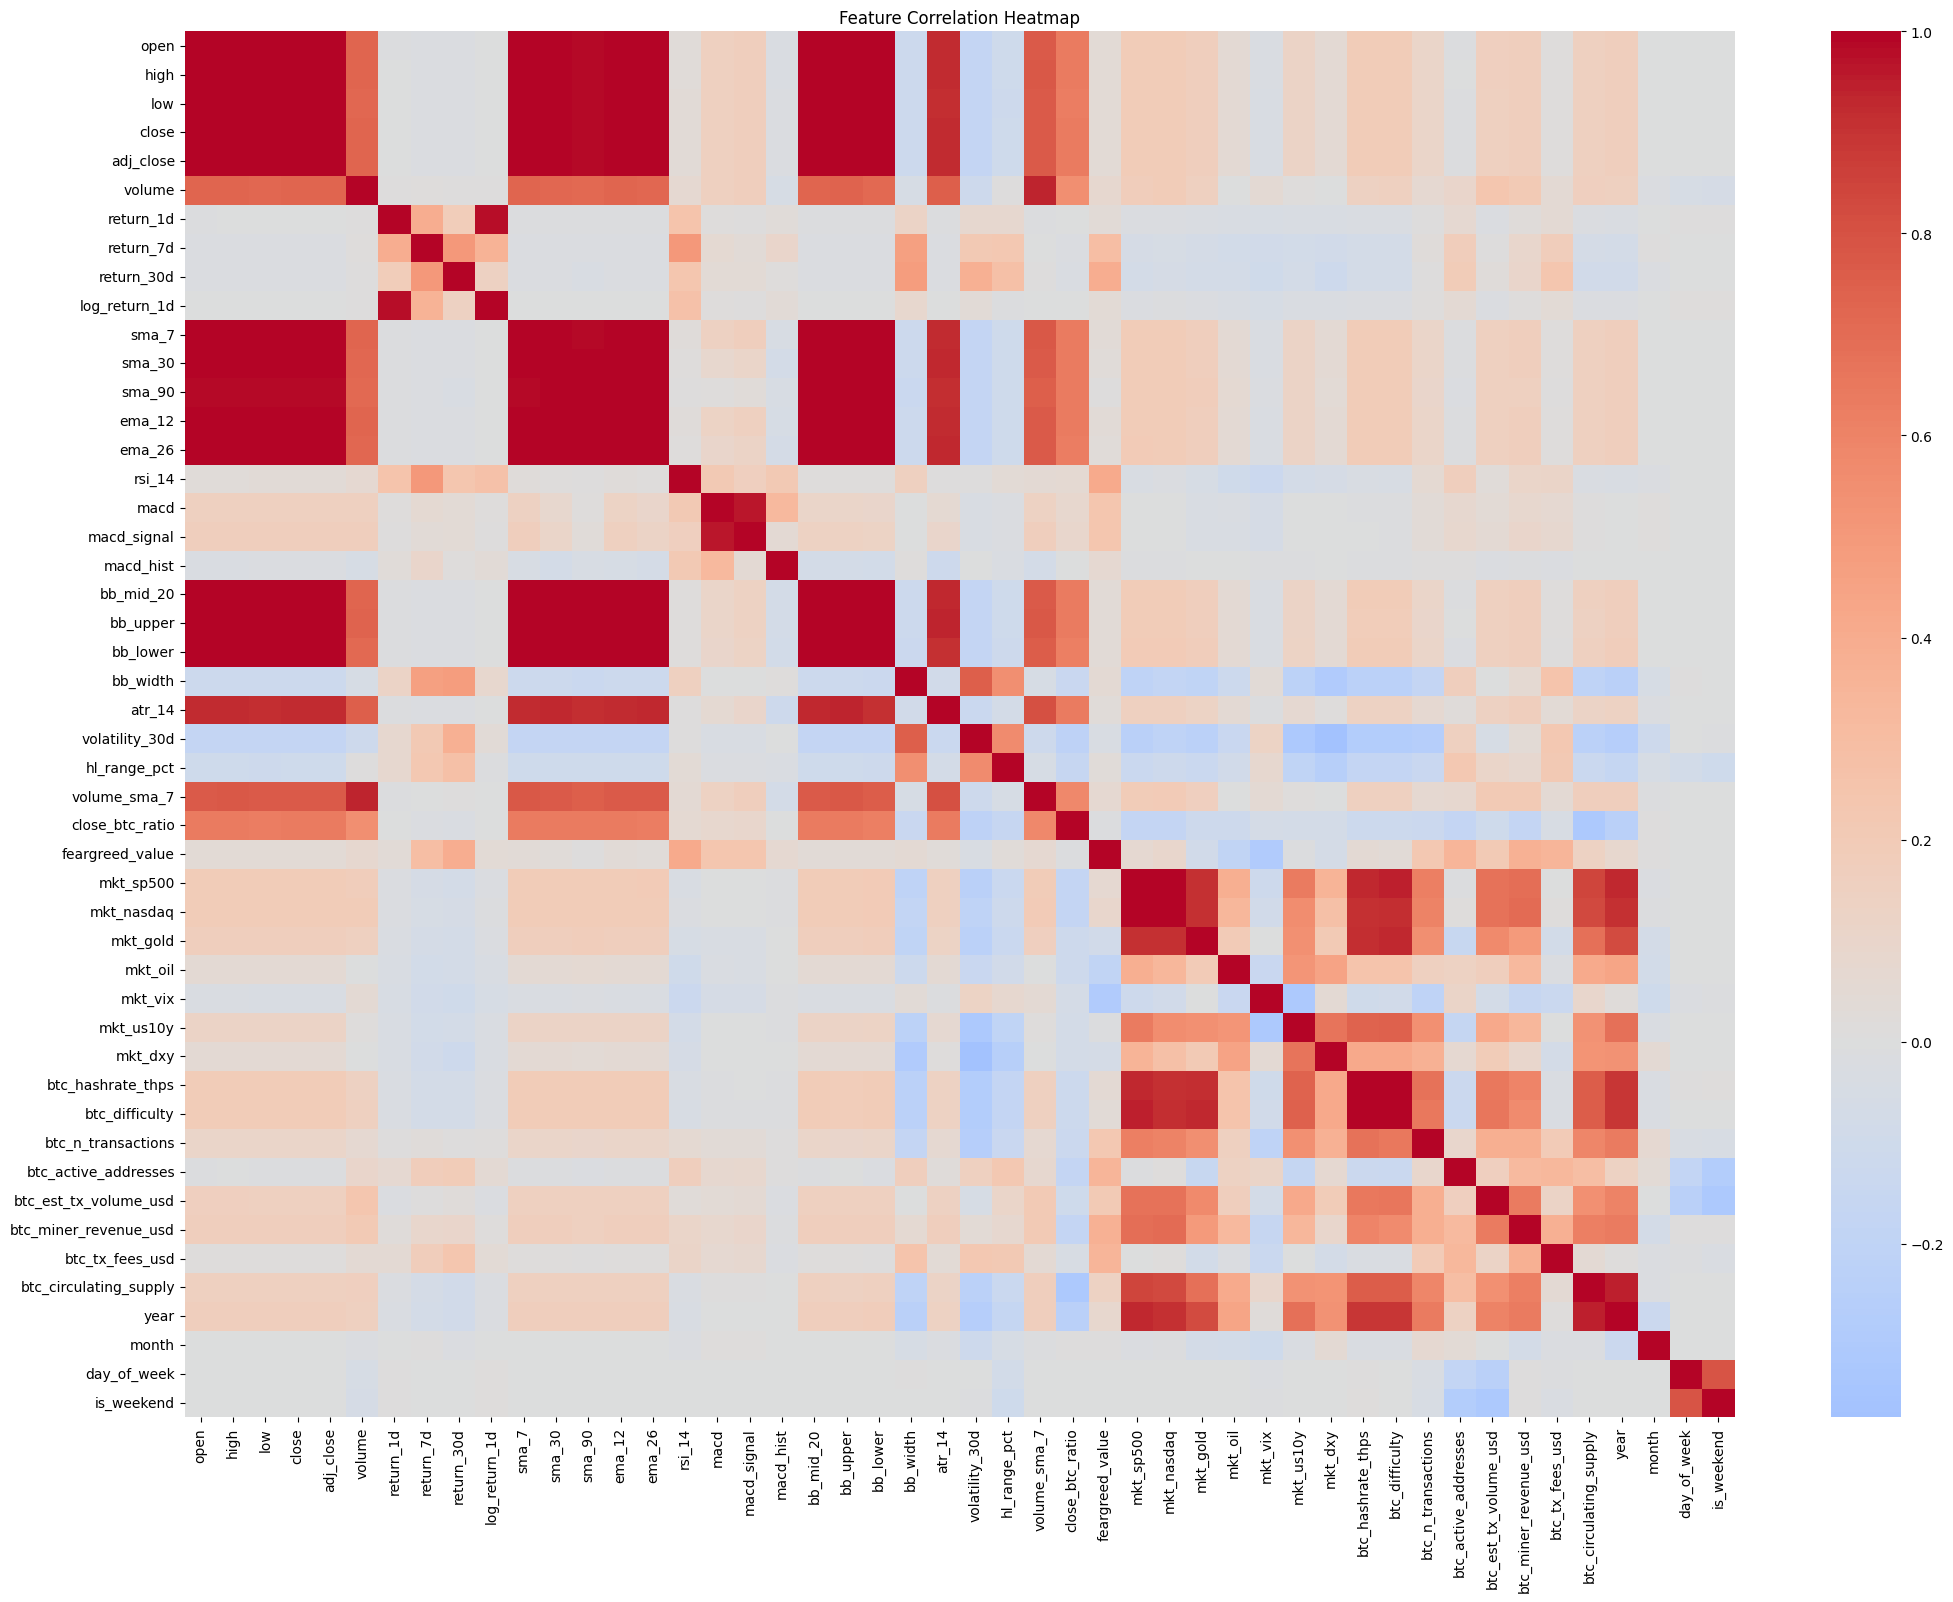

In [29]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(25,18))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=False
)

plt.title('Feature Correlation Heatmap')
plt.show()

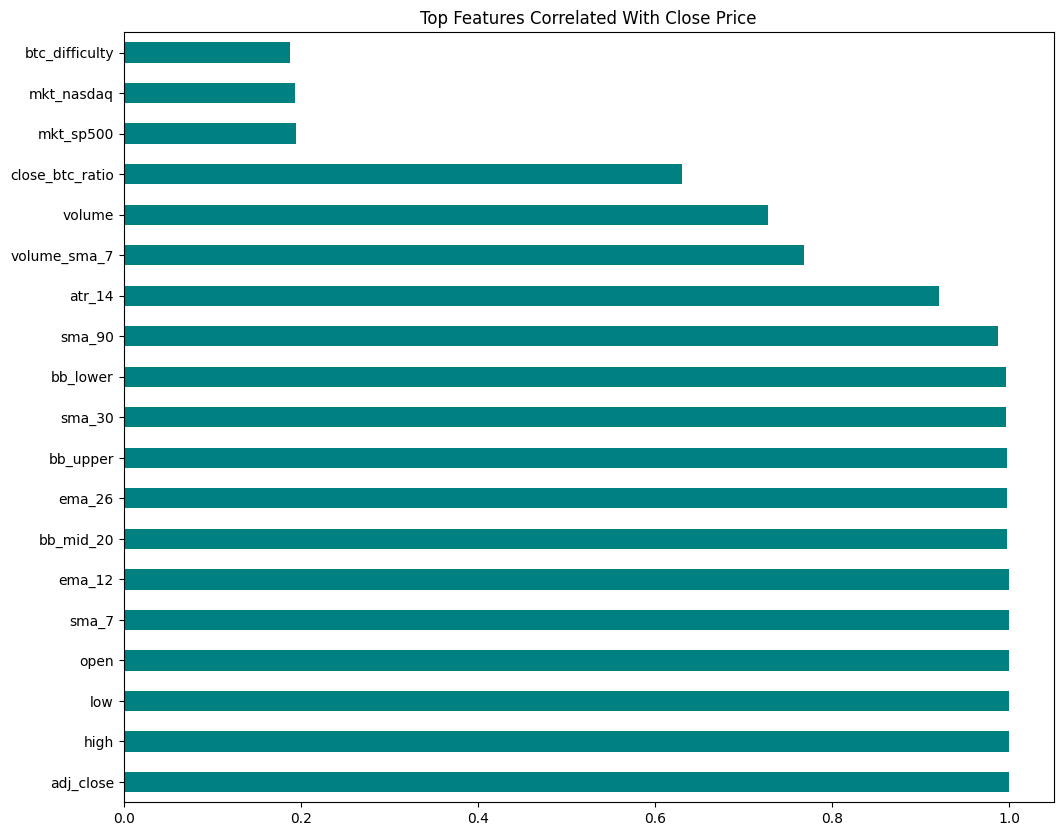

In [30]:
corr_close = numeric_df.corr()['close']

corr_close = corr_close.sort_values(
    ascending=False
)

plt.figure(figsize=(12,10))

corr_close[1:20].plot(
    kind='barh',
    color='teal'
)

plt.title('Top Features Correlated With Close Price')
plt.show()

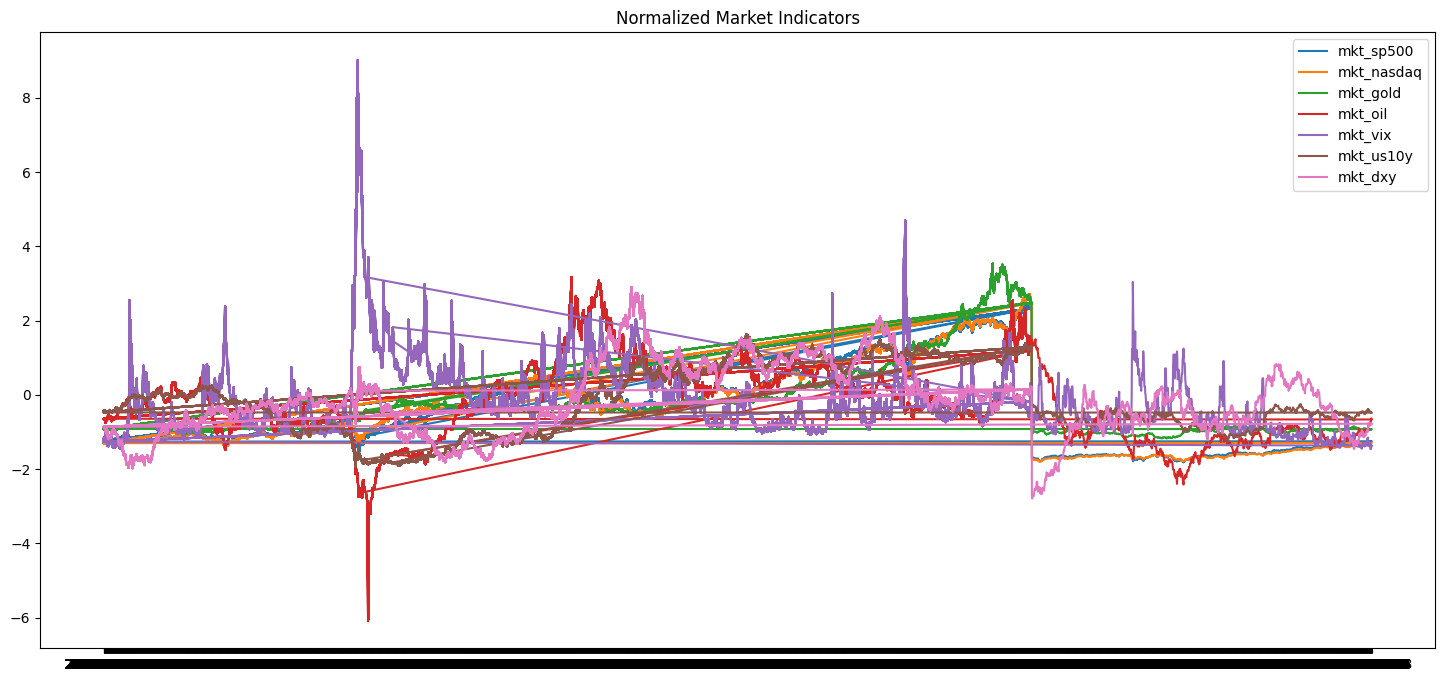

In [31]:
market_cols = [
    'mkt_sp500',
    'mkt_nasdaq',
    'mkt_gold',
    'mkt_oil',
    'mkt_vix',
    'mkt_us10y',
    'mkt_dxy'
]

plt.figure(figsize=(18,8))

for col in market_cols:
    plt.plot(df['date'],
             (df[col]-df[col].mean())/df[col].std(),
             label=col)

plt.legend()
plt.title('Normalized Market Indicators')
plt.show()

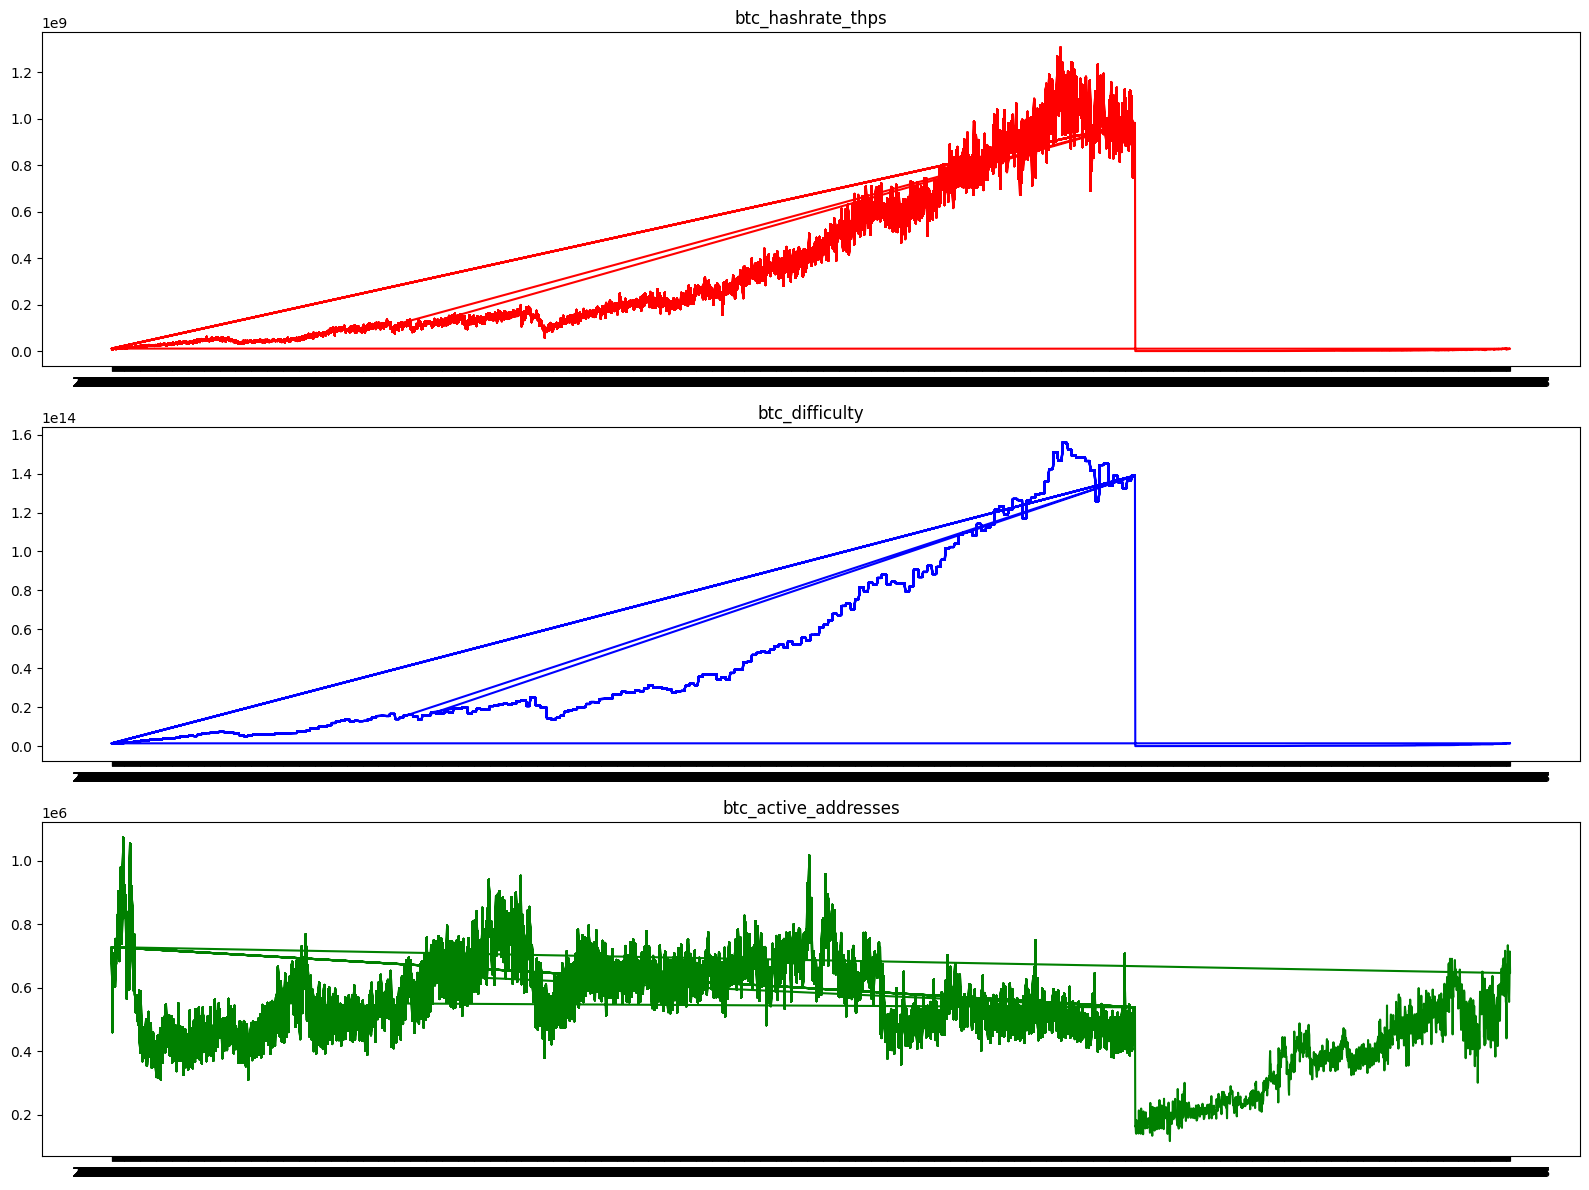

In [32]:
btc_cols = [
    'btc_hashrate_thps',
    'btc_difficulty',
    'btc_active_addresses'
]

fig, axes = plt.subplots(3,1, figsize=(16,12))

colors = ['red','blue','green']

for ax,col,c in zip(axes, btc_cols, colors):
    ax.plot(df['date'],
            df[col],
            color=c)
    ax.set_title(col)

plt.tight_layout()
plt.show()

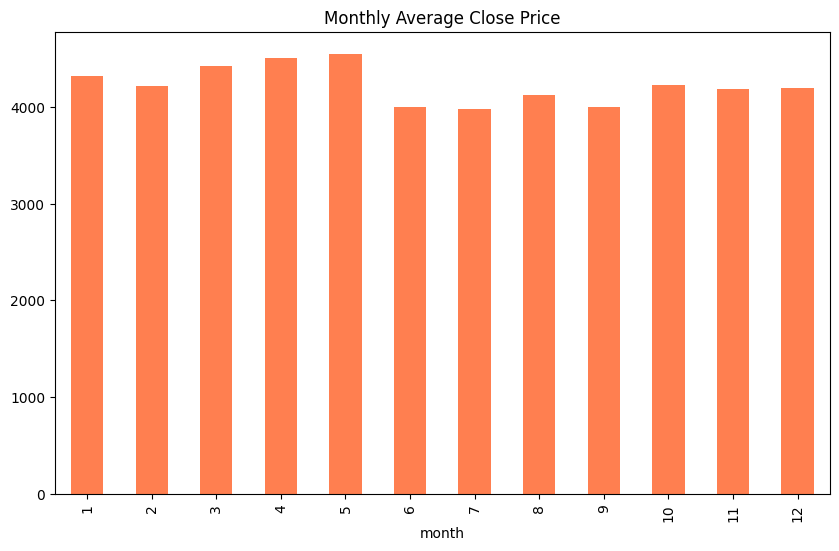

In [33]:
monthly = df.groupby('month')['close'].mean()

plt.figure(figsize=(10,6))

monthly.plot(
    kind='bar',
    color='coral'
)

plt.title('Monthly Average Close Price')
plt.show()

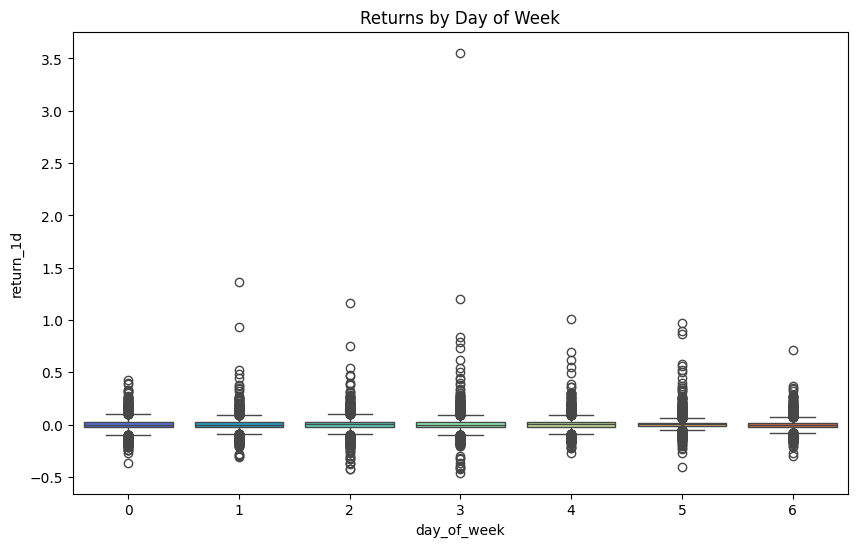

In [34]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='day_of_week',
    y='return_1d',
    data=df,
    palette='rainbow'
)

plt.title('Returns by Day of Week')
plt.show()

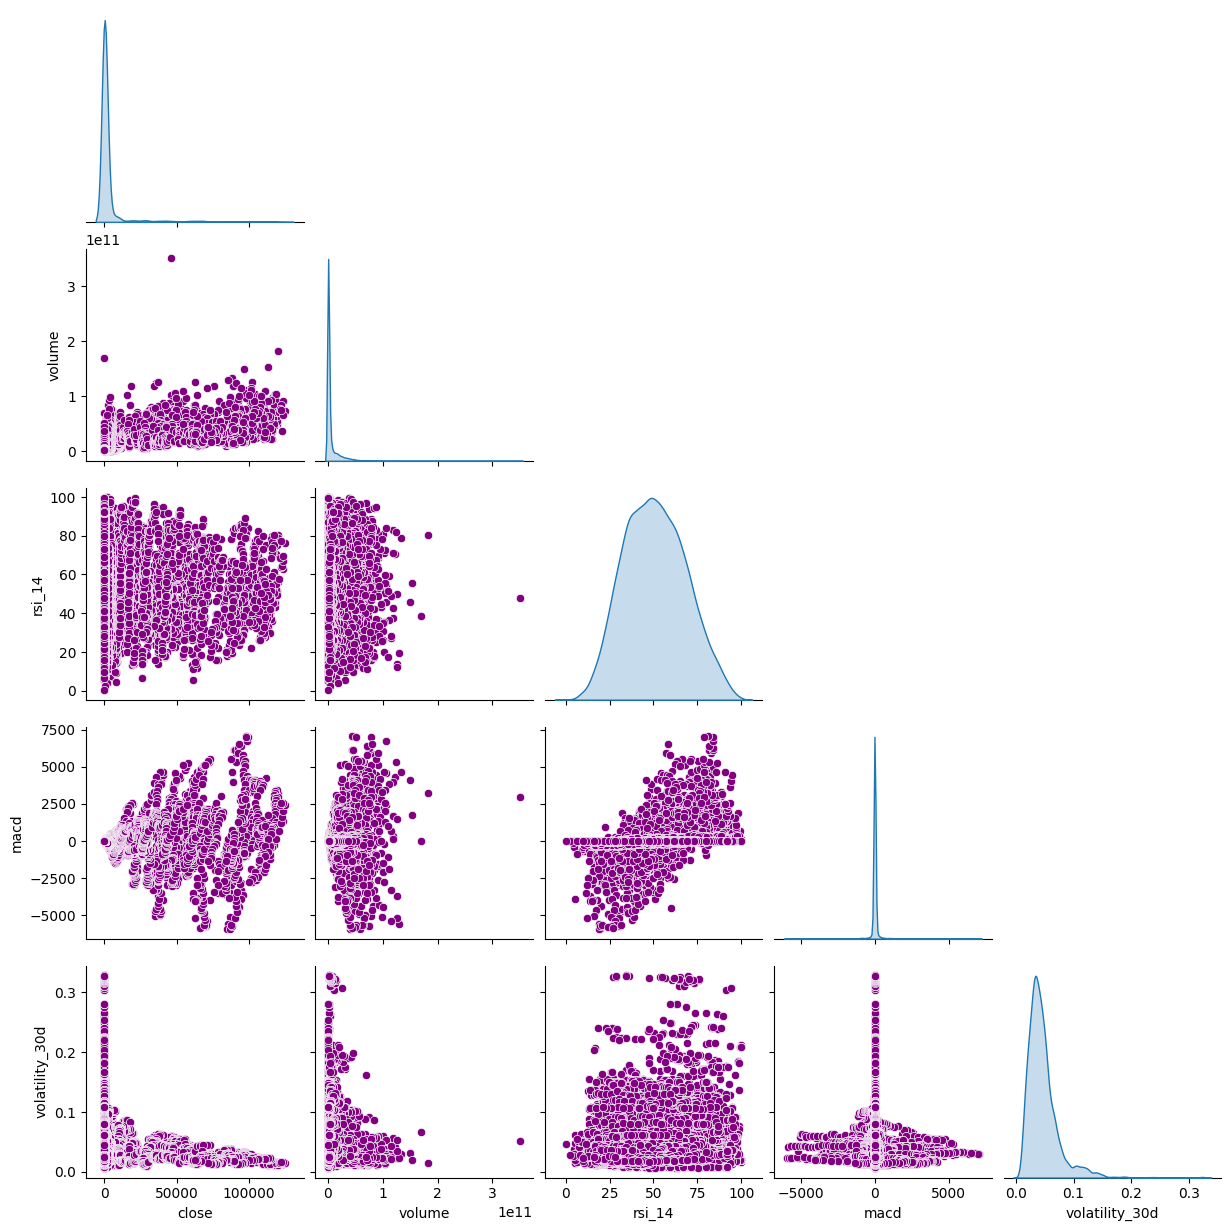

In [35]:
features = [
    'close',
    'volume',
    'rsi_14',
    'macd',
    'volatility_30d'
]

sns.pairplot(
    df[features],
    corner=True,
    diag_kind='kde',
    plot_kws={'color':'purple'}
)

plt.show()

## Feature engineering

In [36]:
df = df.sort_values('date').reset_index(drop=True)

# Target: Tomorrow Close > Today Close
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# Remove last row
df = df[:-1]

In [37]:
df = df.sort_values('date').reset_index(drop=True)

# Target: Tomorrow Close > Today Close
df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

# Remove last row
df = df[:-1]

In [38]:
drop_cols = [
    'target',
    'date',
    'symbol',
    'name'
]

X = df.drop(columns=drop_cols)
y = df['target']


In [39]:
split_index = int(len(df)*0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(24454, 49)
(6114, 49)


In [40]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X_train.select_dtypes(include=['object']).columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )

    X_test[col] = le.transform(
        X_test[col].astype(str)
    )

    encoders[col] = le

In [41]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(
    X_test
)[:,1]

In [45]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(
    X_test
)[:,1]

In [46]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

lgbm.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm.predict(X_test)

lgbm_prob = lgbm.predict_proba(
    X_test
)[:,1]

[LightGBM] [Info] Number of positive: 12319, number of negative: 12135
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008374 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11088
[LightGBM] [Info] Number of data points in the train set: 24454, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503762 -> initscore=0.015049
[LightGBM] [Info] Start training from score 0.015049


In [47]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat.fit(
    X_train,
    y_train
)

cat_pred = cat.predict(X_test)

cat_prob = cat.predict_proba(
    X_test
)[:,1]

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate(y_true,y_pred,y_prob,name):

    print(f"\n{name}")
    print("="*50)

    print("Accuracy :",accuracy_score(y_true,y_pred))
    print("Precision:",precision_score(y_true,y_pred))
    print("Recall   :",recall_score(y_true,y_pred))
    print("F1 Score :",f1_score(y_true,y_pred))
    print("ROC AUC  :",roc_auc_score(y_true,y_prob))

In [49]:
evaluate(y_test,lr_pred,lr_prob,"Logistic Regression")

evaluate(y_test,rf_pred,rf_prob,"Random Forest")

evaluate(y_test,xgb_pred,xgb_prob,"XGBoost")

evaluate(y_test,lgbm_pred,lgbm_prob,"LightGBM")

evaluate(y_test,cat_pred,cat_prob,"CatBoost")


Logistic Regression
Accuracy : 0.6949623814196925
Precision: 0.6370875995449374
Recall   : 0.9120521172638436
F1 Score : 0.7501674480910918
ROC AUC  : 0.7577323040573221

Random Forest
Accuracy : 0.7680732744520772
Precision: 0.7652536929993577
Recall   : 0.7762214983713355
F1 Score : 0.7706985769728332
ROC AUC  : 0.8507994581105779

XGBoost
Accuracy : 0.7530258423290808
Precision: 0.7748414376321353
Recall   : 0.71628664495114
F1 Score : 0.7444143534190928
ROC AUC  : 0.8482124283580237

LightGBM
Accuracy : 0.757769054628721
Precision: 0.7710678949164108
Recall   : 0.7361563517915309
F1 Score : 0.7532077987002166
ROC AUC  : 0.8488922513236912

CatBoost
Accuracy : 0.7690546287209683
Precision: 0.7746852220013254
Recall   : 0.7615635179153094
F1 Score : 0.7680683311432326
ROC AUC  : 0.8566684287346925


In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.73      0.79      0.76      3044
           1       0.77      0.72      0.74      3070

    accuracy                           0.75      6114
   macro avg       0.75      0.75      0.75      6114
weighted avg       0.75      0.75      0.75      6114



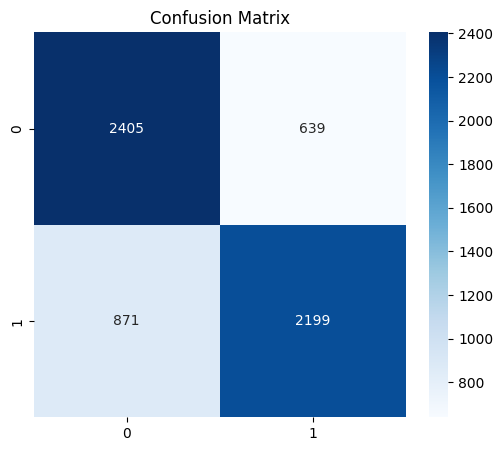

In [51]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    xgb_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

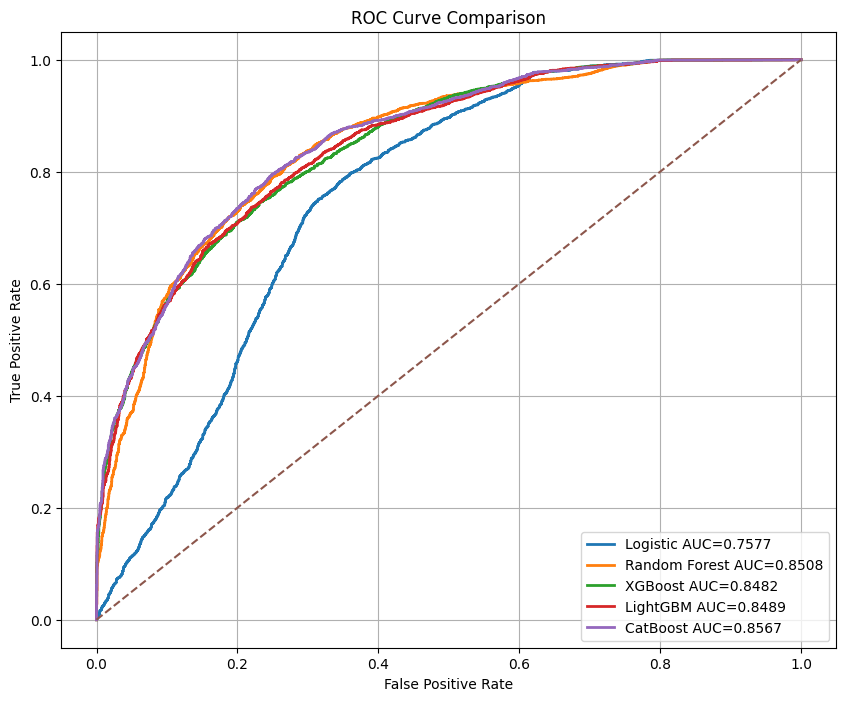

In [52]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10,8))

models = [
    ("Logistic",lr_prob),
    ("Random Forest",rf_prob),
    ("XGBoost",xgb_prob),
    ("LightGBM",lgbm_prob),
    ("CatBoost",cat_prob)
]

for name,prob in models:

    fpr,tpr,_ = roc_curve(
        y_test,
        prob
    )

    auc_score = roc_auc_score(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f"{name} AUC={auc_score:.4f}"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

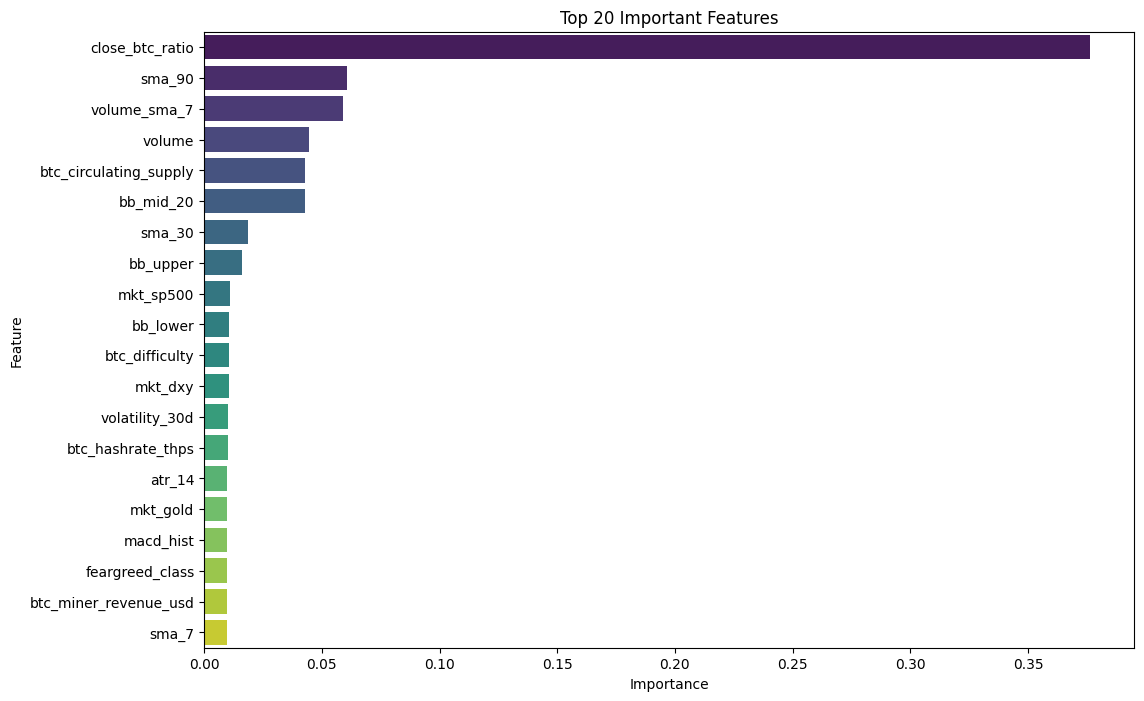

In [53]:
feature_imp = pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':xgb.feature_importances_
})

feature_imp = feature_imp.sort_values(
    by='Importance',
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

sns.barplot(
    data=feature_imp,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Top 20 Important Features")
plt.show()

In [54]:
results = pd.DataFrame({
    'Model':['LR','RF','XGB','LGBM','CAT'],
    'Accuracy':[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred),
        accuracy_score(y_test,lgbm_pred),
        accuracy_score(y_test,cat_pred)
    ],
    'ROC_AUC':[
        roc_auc_score(y_test,lr_prob),
        roc_auc_score(y_test,rf_prob),
        roc_auc_score(y_test,xgb_prob),
        roc_auc_score(y_test,lgbm_prob),
        roc_auc_score(y_test,cat_prob)
    ]
})

print(results.sort_values(
    'ROC_AUC',
    ascending=False
))

  Model  Accuracy   ROC_AUC
4   CAT  0.769055  0.856668
1    RF  0.768073  0.850799
3  LGBM  0.757769  0.848892
2   XGB  0.753026  0.848212
0    LR  0.694962  0.757732


## Thank you...pls upvote!!!!